# Import Required Libraries
Import the necessary libraries, including pandas for data manipulation and matplotlib for plotting.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data from CSV File
Use pandas to read the bm.csv file into a DataFrame.

In [2]:
df = pd.read_csv('bm.csv')
print(f"Data loaded successfully. Shape: {df.shape}")

Data loaded successfully. Shape: (14, 2)


# Explore the Dataset
Display the first few rows of the dataset and check the data types to understand the structure.

In [3]:
print("First few rows:")
print(df.head())
print("\nData info:")
print(df.info())

First few rows:
         vbm        bm
0 -60.108993  3.490802
1 -54.314514  4.522175
2 -50.055921  3.894696
3 -45.378450  1.045798
4 -40.770792  1.312657

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   vbm     14 non-null     float64
 1   bm      14 non-null     float64
dtypes: float64(2)
memory usage: 356.0 bytes
None


# Bootstrap Analysis
Generate bootstrap samples and fit each to bm = Am*exp(-vbm/zm) to estimate parameter uncertainties.

In [4]:
from scipy.optimize import curve_fit
import numpy as np

# Define the exponential decay function
def exp_decay(vbm, Am, zm):
    return Am * np.exp(-vbm / zm)

# Initial guesses for parameters
initial_guess = [0.11, 18]

# Bootstrap parameters
n_bootstrap = 8000
n_samples = len(df)

# Arrays to store bootstrap results
Am_bootstrap = []
zm_bootstrap = []

# Perform bootstrap resampling
np.random.seed(42)  # For reproducibility

for i in range(n_bootstrap):
    # Resample with replacement
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    vbm_resample = df['vbm'].iloc[indices].values
    bm_resample = df['bm'].iloc[indices].values
    
    try:
        # Fit the resampled data
        popt_boot, _ = curve_fit(exp_decay, vbm_resample, bm_resample, p0=initial_guess)
        Am_bootstrap.append(popt_boot[0])
        zm_bootstrap.append(popt_boot[1])
    except:
        # Skip if fit fails
        continue

# Convert to numpy arrays
Am_bootstrap = np.array(Am_bootstrap)
zm_bootstrap = np.array(zm_bootstrap)

print(f"Bootstrap Analysis Results (n={len(Am_bootstrap)} successful fits):")
print(f"\nParameter Am:")
print(f"  Mean = {np.mean(Am_bootstrap):.6f}")
print(f"  Std  = {np.std(Am_bootstrap):.6f}")
print(f"\nParameter zm:")
print(f"  Mean = {np.mean(zm_bootstrap):.6f}")
print(f"  Std  = {np.std(zm_bootstrap):.6f}")

/var/folders/nw/qqw2xvy17fv7cxtzjlhg366r0000gn/T/ipykernel_58286/1244592567.py:6: RuntimeWarning: overflow encountered in exp
  return Am * np.exp(-vbm / zm)


Bootstrap Analysis Results (n=8000 successful fits):

Parameter Am:
  Mean = 0.123151
  Std  = 0.077930

Parameter zm:
  Mean = 15.934531
  Std  = 4.242567


# Plot Data with Bootstrap Mean Fit and Confidence Limits
Show the mean fit from bootstrap analysis with confidence intervals.

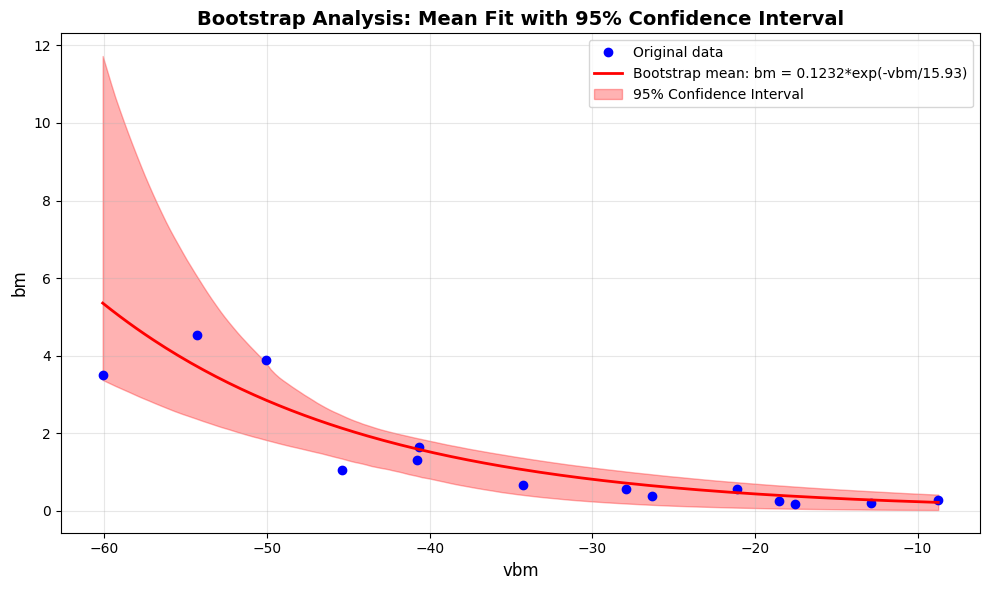

In [5]:
plt.figure(figsize=(10, 6))

# Plot original data
plt.plot(df['vbm'], df['bm'], 'o', label='Original data', markersize=6, color='blue')

# Generate smooth curve for mean bootstrap fit
vbm_smooth = np.linspace(df['vbm'].min(), df['vbm'].max(), 200)
Am_mean = np.mean(Am_bootstrap)
zm_mean = np.mean(zm_bootstrap)
bm_mean = exp_decay(vbm_smooth, Am_mean, zm_mean)

# Calculate confidence limits (95% CI using 2.5th and 97.5th percentiles)
bm_curves = np.array([exp_decay(vbm_smooth, Am_bootstrap[i], zm_bootstrap[i]) 
                      for i in range(len(Am_bootstrap))])
bm_lower = np.percentile(bm_curves, 2.5, axis=0)
bm_upper = np.percentile(bm_curves, 97.5, axis=0)

# Plot mean fit and confidence interval
plt.plot(vbm_smooth, bm_mean, '-', linewidth=2, color='red', 
         label=f'Bootstrap mean: bm = {Am_mean:.4f}*exp(-vbm/{zm_mean:.2f})')
plt.fill_between(vbm_smooth, bm_lower, bm_upper, alpha=0.3, color='red', 
                 label='95% Confidence Interval')

plt.xlabel('vbm', fontsize=12)
plt.ylabel('bm', fontsize=12)
plt.title('Bootstrap Analysis: Mean Fit with 95% Confidence Interval', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Histograms of Bootstrap Parameters
Distribution of Am and zm from bootstrap resampling.

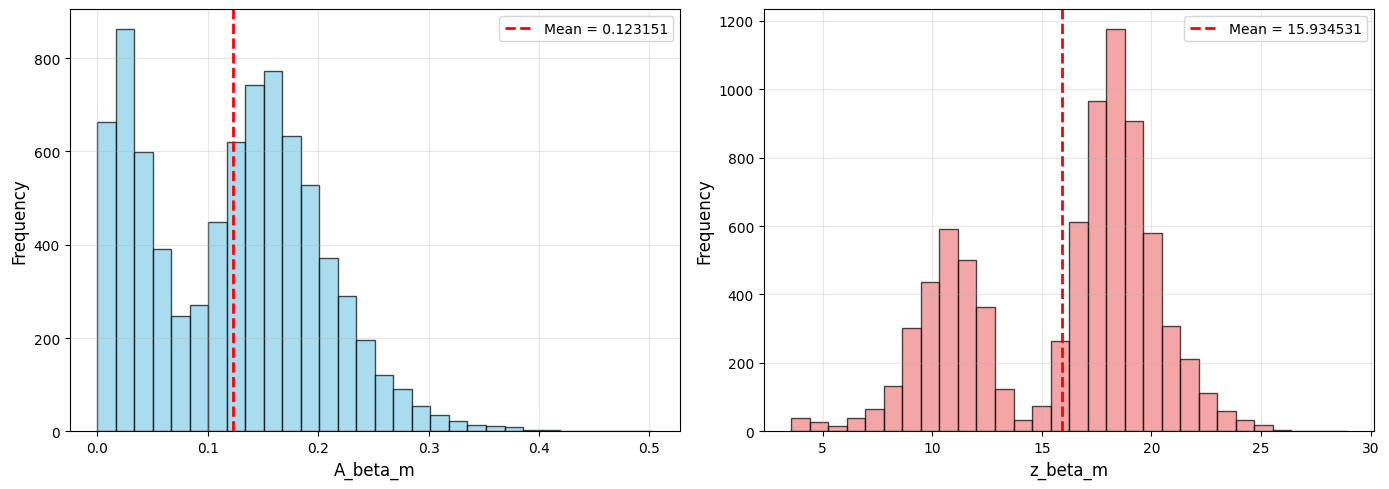

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of Am
axes[0].hist(Am_bootstrap, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(np.mean(Am_bootstrap), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(Am_bootstrap):.6f}')
axes[0].set_xlabel('A_beta_m', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Histogram of zm
axes[1].hist(zm_bootstrap, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].axvline(np.mean(zm_bootstrap), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(zm_bootstrap):.6f}')
axes[1].set_xlabel('z_beta_m', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Parameter Correlation: Am vs zm
Scatter plot showing the relationship between fitted Am and zm parameters from bootstrap samples.

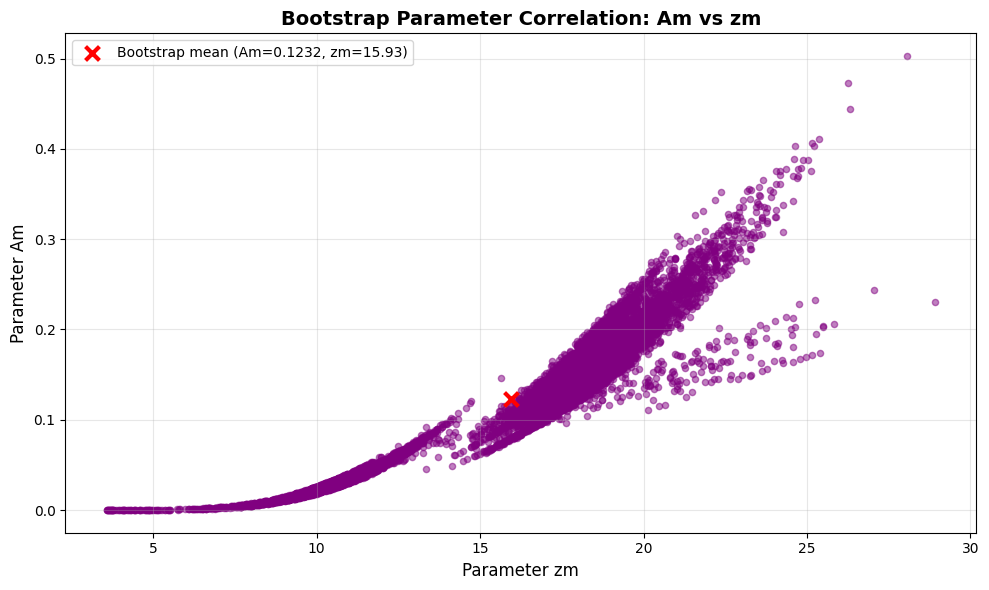


Correlation coefficient between Am and zm: 0.9426


In [7]:
plt.figure(figsize=(10, 6))

# Calculate mean parameters
Am_mean = np.mean(Am_bootstrap)
zm_mean = np.mean(zm_bootstrap)

# Scatter plot of Am vs zm
plt.scatter(zm_bootstrap, Am_bootstrap, alpha=0.5, s=20, color='purple')
plt.scatter(zm_mean, Am_mean, color='red', s=100, marker='x', linewidths=3, 
            label=f'Bootstrap mean (Am={Am_mean:.4f}, zm={zm_mean:.2f})')

plt.xlabel('Parameter zm', fontsize=12)
plt.ylabel('Parameter Am', fontsize=12)
plt.title('Bootstrap Parameter Correlation: Am vs zm', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation coefficient
correlation = np.corrcoef(Am_bootstrap, zm_bootstrap)[0, 1]
print(f"\nCorrelation coefficient between Am and zm: {correlation:.4f}")